# Jupyter Notebook Report

The report is a critical component of your project. It should focus on:

- Clear justification of design choices, explaining how each component in your method contributes to performance
- Detailed technical descriptions of your solution
- Strong quantitative and qualitative analyses, demonstrating and explaining the ability of your solution

Team members: 
- Toni Nigro (357828)  
- Samuel Waridel (330169)   
- Téo Wermeille (363215)

In [1]:
# main imports for the project
import pandas as pd
import matplotlib.pyplot as plt
from utils.group_detect import *
from utils.card_color_detect import *
import cv2

In [2]:
train_y = pd.read_csv('data/train.csv')
display(train_y.head())

,image_id,center_card,active_player,player_1_cards,player_2_cards,player_3_cards,player_4_cards
0,L1000770,y_1,p3,EMPTY,y_4;g_2;r_3,r_skip;y_2;b_5,EMPTY
1,L1000771,r_5,p1,y_7;y_8;g_4,EMPTY,r_9;y_0,EMPTY
2,L1000772,r_9,p2,y_8;b_6;g_3,b_skip;r_0;r_3,r_6;g_2;r_9,b_draw_2;y_7
3,L1000773,y_8,p4,r_1;wild;g_2,EMPTY,draw_4;g_reverse;y_1,y_reverse;r_3
4,L1000774,r_4,p3,g_4;g_8;r_7;b_3,r_9;g_3,wild;y_3;r_8,b_7;b_6


In [3]:
def split_uno_regions(image_path):
    """
    Découpe l'image UNO en 5 régions : 4 joueurs + carte centrale.
    Retourne un dict {nom: np.ndarray (H, W, 3)}
    """
    img = plt.imread(image_path)  # np.ndarray RGB, valeurs 0-255
    H, W = img.shape[:2]

    regions = {
        "player_1": img[0          : int(0.30*H), int(0.20*W) : int(0.80*W)],
        "player_2": img[int(0.2*H): int(0.8*H), 0           : int(0.22*W)],
        "player_3": img[int(0.70*H): H,           int(0.20*W) : int(0.80*W)],
        "player_4": img[int(0.2*H): int(0.8*H), int(0.78*W) : W          ],
        "center"  : img[int(0.35*H): int(0.65*H), int(0.35*W) : int(0.65*W)],
    }
    return regions


def visualize_regions(image_path):
    """Affiche les 5 régions côte à côte pour validation."""
    regions = split_uno_regions(image_path)
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for ax, (name, crop) in zip(axes, regions.items()):
        ax.imshow(crop)
        ax.set_title(name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

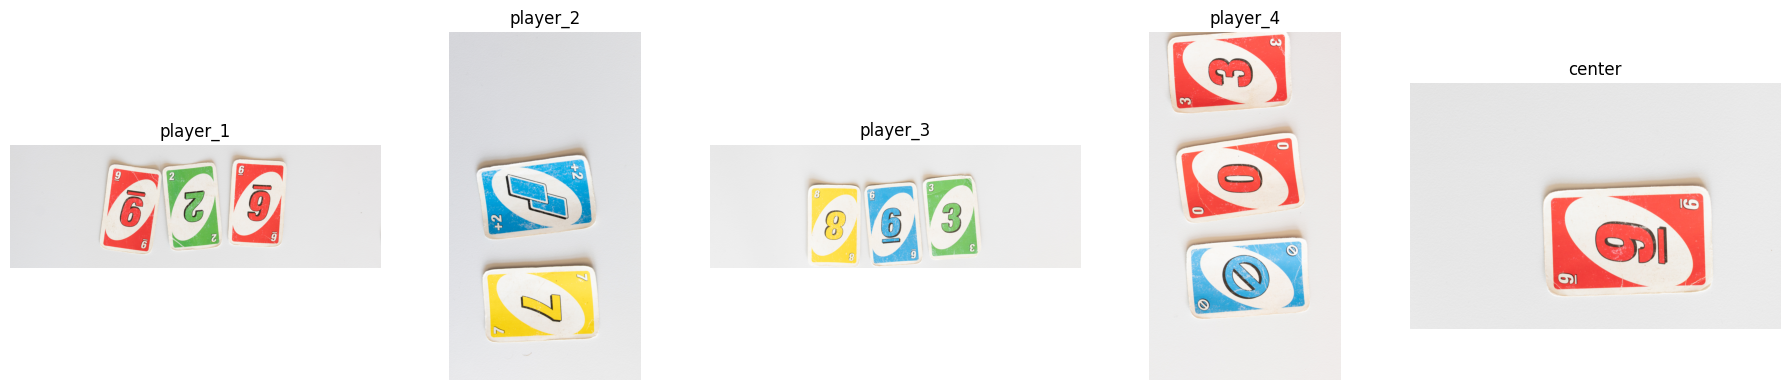

In [4]:
image_test_path = "images/L1000772.jpg"
visualize_regions(image_test_path)
regions = split_uno_regions(image_test_path)

# Accès individuel
center_crop = regions["center"]       # shape: (H', W', 3)
p1_crop     = regions["player_1"]

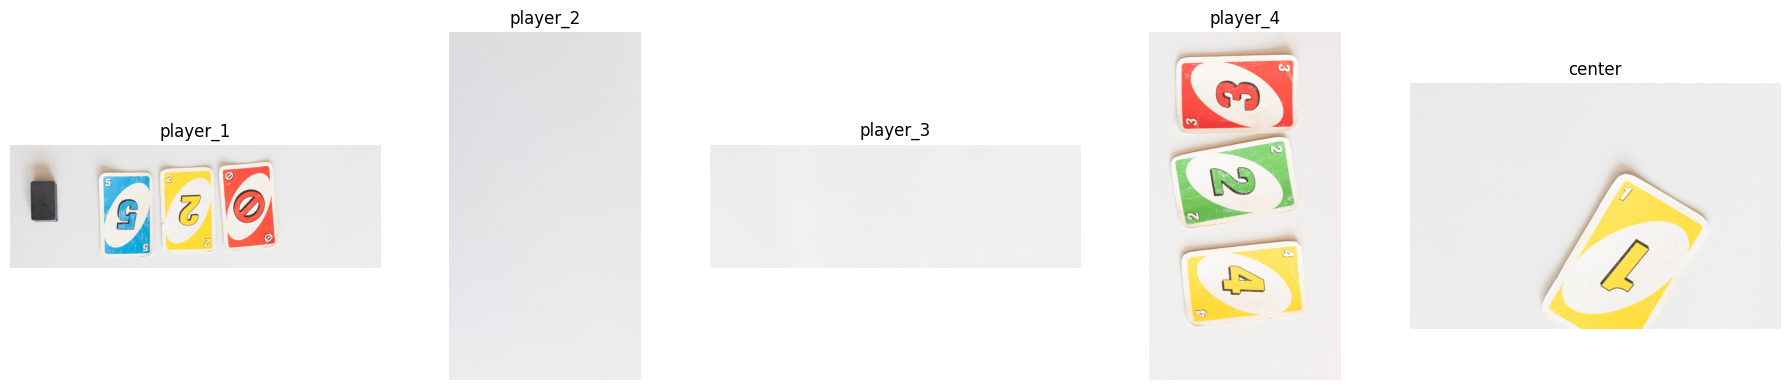

In [9]:
image_path = "data/train_images/L1000770.jpg"
visualize_regions(image_path)
regions = split_uno_regions(image_path)

player_1: (798, 2400, 3)
Card 0 is unknown
Card 1 is unknown
Card 2 is yellow
Card 3 is blue
Card 4 is blue
Card 5 is yellow
Card 6 is blue
Card 7 is blue
Card 8 is yellow


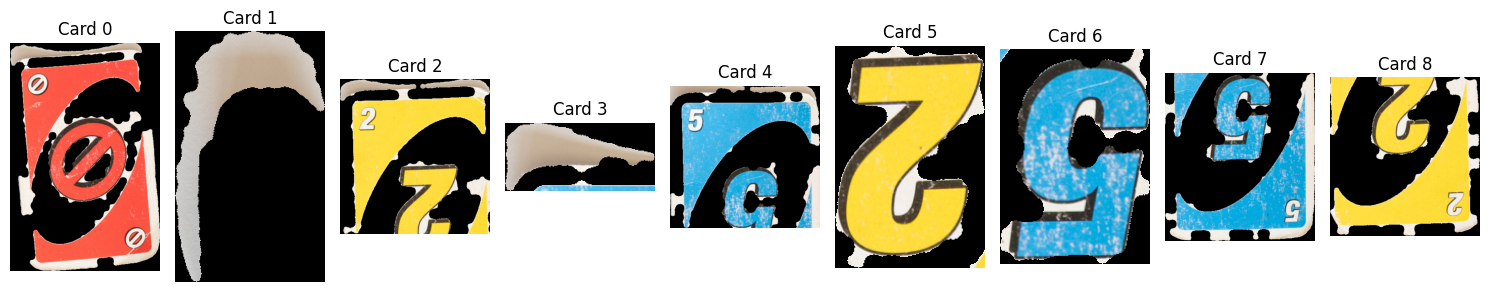

player_2: (1597, 880, 3)


ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x500 with 0 Axes>

In [12]:
for region in regions:
    print(f"{region}: {regions[region].shape}")
    detect_card_color_from_group_image(regions[region], color_detection_tolerance=0.2, plot=True)